In [ ]:
pip install nltk scikit-learn pandas numpy matplotlib seaborn

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Accuracy: 0.2

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.08      1.00      0.14         1
           3       0.00      0.00      0.00         2
           4       1.00      0.50      0.67         2
           5       0.00      0.00      0.00         4
           6       1.00      0.33      0.50         3
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1

    accuracy                           0.20        15
   macro avg       0.26      0.23      0.16        15
weighted avg       0.34      0.20      0.20        15



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


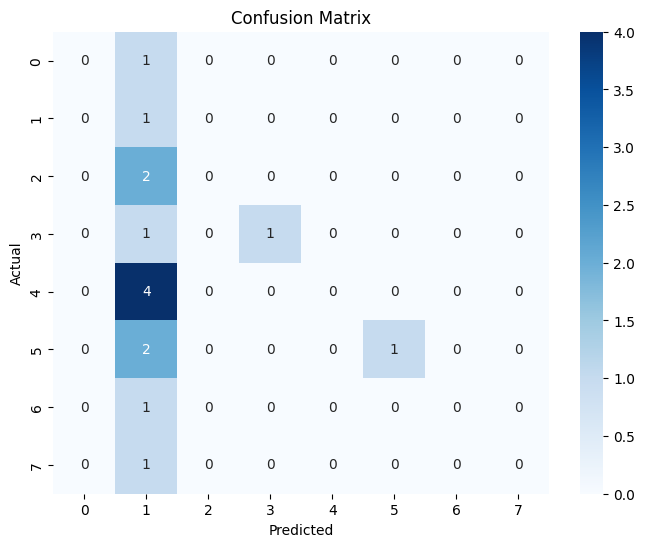


Model Saved Successfully

CollegeBot Started
Ask about:
Admissions
Fees
Courses
Hostel
Placements
Type 'bye' to exit

You: hi
[Intent: unknown, Confidence: 0.22]
Bot: Please ask a college-related question.
You: how are you
[Intent: greeting, Confidence: 0.30]
Bot: Hi! How can I help you today?
You: admission process
[Intent: admission, Confidence: 0.43]
Bot: Admissions are currently open. Please check the college admission portal.
You: hostel fees
[Intent: fees, Confidence: 0.30]
Bot: Fee details are available on the college website.
You: placement record
[Intent: placements, Confidence: 0.32]
Bot: The college provides placement assistance and internship opportunities.
You: thank you
[Intent: unknown, Confidence: 0.17]
Bot: Please ask a college-related question.
You: bye
[Intent: unknown, Confidence: 0.17]
Bot: I can help with admissions, fees, courses, hostel and placements.


In [ ]:
import random
import pickle
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
accuracy_score,
classification_report,
confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

# ======================================================

# NLTK DOWNLOADS

# ======================================================

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# ======================================================

# DATASET

# ======================================================

data = {
"greeting":[
    "hello","hi","hey","good morning","good evening",
    "greetings","howdy","how are you",
    "how are you doing","nice to meet you"
],

"farewell":[
    "bye","goodbye","see you","take care",
    "quit","exit"
],

"admission":[
    "how to apply",
    "admission process",
    "application form",
    "enrollment process",
    "registration process",
    "how can i join",
    "admission date",
    "how can i get admission",
    "admission enquiry"
],

"fees":[
    "fees",
    "fee structure",
    "tuition fee",
    "semester fee",
    "annual fee",
    "college fee",
    "payment details",
    "fee details",
    "how much are the fees"
],

"courses":[
    "courses",
    "degrees",
    "available programs",
    "departments",
    "computer science",
    "mba",
    "mca",
    "what can you do",
    "college information",
    "tell me about college"
],

"hostel":[
    "hostel",
    "accommodation",
    "dormitory",
    "room facility",
    "where can i stay",
    "girls hostel",
    "boys hostel",
    "hostel facility"
],

"placements":[
    "placement",
    "salary package",
    "job opportunities",
    "campus recruitment",
    "highest package",
    "average package",
    "internships",
    "placement record"
],

"thanks":[
    "thanks","thank you","awesome","great","helpful"
],

"complaint":[
    "bad service","poor service","not satisfied","unhappy","issue","problem","disappointed"
]

}

# ======================================================

# RESPONSES

# ======================================================

responses = {

"greeting":[
    "Hello! Welcome to CollegeBot.",
    "Hi! How can I help you today?"
],

"farewell":[
    "Goodbye! Have a great day."
],

"admission":[
    "Admissions are currently open. Please check the college admission portal."
],

"fees":[
    "Fee details are available on the college website."
],

"courses":[
    "We offer B.Tech, BCA, MCA, MBA and several other programs."
],

"hostel":[
    "Separate hostel facilities are available for boys and girls."
],

"placements":[
    "The college provides placement assistance and internship opportunities."
],

"thanks":[
    "You're welcome!",
    "Glad I could help."
],

"complaint":[
    "Sorry for the inconvenience. Please explain your issue."
],

"unknown":[
    "I can help with admissions, fees, courses, hostel and placements.",
    "Please ask a college-related question."
]

}

# ======================================================

# PREPROCESSING

# ======================================================

def advanced_preprocess(text):
    tokens = word_tokenize(text.lower())

    tokens = [t for t in tokens if t.isalpha()]

    custom_stopwords = stop_words - {
        "how","what","when","where",
        "can","which","who","why"
    }

    tokens = [t for t in tokens if t not in custom_stopwords]

    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)


# ======================================================

# PREPARE DATA

# ======================================================

X = []
y = []

for tag, patterns in data.items():
    for pattern in patterns:

        X.append(
            advanced_preprocess(pattern)
        )

        y.append(tag)


# ======================================================

# TF-IDF

# ======================================================

tfidf = TfidfVectorizer(
ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(X)

# ======================================================

# LABEL ENCODING

# ======================================================

le = LabelEncoder()

y_encoded = le.fit_transform(y)

# ======================================================

# TRAIN TEST SPLIT

# ======================================================

X_train, X_test, y_train, y_test = train_test_split(
X_tfidf,
y_encoded,
test_size=0.2,
random_state=42
)

# ======================================================

# TRAIN MODEL

# ======================================================

model = LogisticRegression(
max_iter=1000
)

model.fit(X_train, y_train)

# ======================================================

# EVALUATION

# ======================================================

predictions = model.predict(X_test)

print("\nAccuracy:",
accuracy_score(y_test,predictions))

print("\nClassification Report:\n")
print(
classification_report(
y_test,
predictions
)
)

# ======================================================

# CONFUSION MATRIX

# ======================================================

cm = confusion_matrix(
y_test,
predictions
)

plt.figure(figsize=(8,6))

sns.heatmap(
cm,
annot=True,
fmt='d',
cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
"chatbot_confusion_matrix.png"
)

plt.show()

# ======================================================

# SAVE MODEL

# ======================================================

pickle.dump(
tfidf,
open("chatbot_tfidf.pkl","wb")
)

pickle.dump(
model,
open("chatbot_model.pkl","wb")
)

print("\nModel Saved Successfully")

# ======================================================

# PREDICTION FUNCTION

# ======================================================

def predict_intent(user_input):
    processed = advanced_preprocess(
        user_input
    )

    if processed.strip() == "":
        return "unknown",0.0

    vector = tfidf.transform(
        [processed]
    )

    probabilities = model.predict_proba(
        vector
    )[0]

    confidence = max(probabilities)

    predicted_class = model.predict(
        vector
    )[0]

    tag = le.inverse_transform(
        [predicted_class]
    )[0]

    if confidence < 0.30:
        return "unknown",confidence

    return tag,confidence


# ======================================================

# CHATBOT

# ======================================================

def chat():
    print("\n====================")
    print("CollegeBot Started")
    print("====================")
    print("Ask about:")
    print("Admissions")
    print("Fees")
    print("Courses")
    print("Hostel")
    print("Placements")
    print("Type 'bye' to exit\n")

    while True:

        user = input("You: ")

        tag, confidence = predict_intent(
            user
        )

        print(
            f"[Intent: {tag}, Confidence: {confidence:.2f}]"
        )

        print(
            "Bot:",
            random.choice(
                responses[tag]
            )
        )

        if tag == "farewell":
            break


# ======================================================

# RUN

# ======================================================

if __name__ == "__main__":
    chat()